# 06 — Driver Rating Storytelling

This notebook turns the teammate-normalized Formula 1 driver ratings into a portfolio-ready results story.

It uses the outputs from Notebook 5:

- `driver_teammate_ratings_all.csv`
- `driver_teammate_ratings_30plus.csv`
- `teammate_model_dataset.csv`
- `teammate_gap_cap_sensitivity.csv`
- `teammate_min_race_threshold_sensitivity.csv`

The goal is not to refit the model. The goal is to explain the results clearly, validate the main interpretation, and export useful visuals for the GitHub repository or dashboard.

## Cell 1 — Setup

In [13]:
# ==============================================================================
# CELL 1 — SETUP
# ==============================================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("/Users/lukeweeklund/F1 Project")
OUTPUTS = PROJECT_ROOT / "data" / "outputs"
FIGURES = OUTPUTS / "figures"

FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 80)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print(f"Project root: {PROJECT_ROOT}")
print(f"Notebook 5 outputs: {OUTPUTS}")
print(f"Figure output folder: {FIGURES}")

Project root: /Users/lukeweeklund/F1 Project
Notebook 5 outputs: /Users/lukeweeklund/F1 Project/data/outputs
Figure output folder: /Users/lukeweeklund/F1 Project/data/outputs/figures


## Cell 2 — Load Notebook 5 Outputs

In [14]:
# ==============================================================================
# CELL 2 — LOAD NOTEBOOK 5 OUTPUTS
# ==============================================================================

required_files = {
    "ratings_all": OUTPUTS / "driver_teammate_ratings_all.csv",
    "ratings_qualified": OUTPUTS / "driver_teammate_ratings_30plus.csv",
    "model_dataset": OUTPUTS / "teammate_model_dataset.csv",
    "gap_cap_sensitivity": OUTPUTS / "teammate_gap_cap_sensitivity.csv",
    "min_race_sensitivity": OUTPUTS / "teammate_min_race_threshold_sensitivity.csv",
}

missing_files = [str(path) for path in required_files.values() if not path.exists()]

if missing_files:
    missing_text = "\n- ".join(missing_files)
    raise FileNotFoundError(
        "Notebook 6 requires Notebook 5 outputs first.\n\n"
        f"Missing files:\n- {missing_text}"
    )

ratings_all = pd.read_csv(required_files["ratings_all"])
ratings_qualified = pd.read_csv(required_files["ratings_qualified"])
model_dataset = pd.read_csv(required_files["model_dataset"])
gap_cap_sensitivity = pd.read_csv(required_files["gap_cap_sensitivity"])
min_race_sensitivity = pd.read_csv(required_files["min_race_sensitivity"])

print("Loaded Notebook 5 outputs:")
print(f"- ratings_all:          {ratings_all.shape}")
print(f"- ratings_qualified:    {ratings_qualified.shape}")
print(f"- model_dataset:        {model_dataset.shape}")
print(f"- gap_cap_sensitivity:  {gap_cap_sensitivity.shape}")
print(f"- min_race_sensitivity: {min_race_sensitivity.shape}")

Loaded Notebook 5 outputs:
- ratings_all:          (83, 17)
- ratings_qualified:    (58, 18)
- model_dataset:        (6908, 135)
- gap_cap_sensitivity:  (5, 3)
- min_race_sensitivity: (7, 5)


## Cell 3 — Validate Inputs

In [15]:
# ==============================================================================
# CELL 3 — VALIDATE INPUTS
# ==============================================================================

required_rating_columns = [
    "driver_id",
    "driver_name",
    "teammate_driver_rating",
    "races",
    "reliability",
]

required_context_columns = [
    "teammate_win_rate",
    "avg_finish_gap",
    "qualifying_win_rate",
    "avg_points_gap",
    "avg_car_score",
]

missing_rating_cols = [c for c in required_rating_columns if c not in ratings_all.columns]
missing_context_cols = [c for c in required_context_columns if c not in ratings_all.columns]

if missing_rating_cols:
    raise ValueError(f"ratings_all is missing required rating columns: {missing_rating_cols}")

if missing_context_cols:
    print(f"Warning: ratings_all is missing some context columns: {missing_context_cols}")

duplicate_drivers = ratings_all["driver_id"].duplicated().sum()
qualified_duplicate_drivers = ratings_qualified["driver_id"].duplicated().sum()

validation_summary = {
    "all_driver_rows": len(ratings_all),
    "qualified_driver_rows": len(ratings_qualified),
    "model_dataset_rows": len(model_dataset),
    "duplicate_driver_ids_all": int(duplicate_drivers),
    "duplicate_driver_ids_qualified": int(qualified_duplicate_drivers),
    "missing_main_rating_all": int(ratings_all["teammate_driver_rating"].isna().sum()),
    "missing_main_rating_qualified": int(ratings_qualified["teammate_driver_rating"].isna().sum()),
}

print("Validation summary:")
for key, value in validation_summary.items():
    print(f"{key}: {value}")

if duplicate_drivers == 0 and qualified_duplicate_drivers == 0 and validation_summary["missing_main_rating_all"] == 0:
    print("\nVERDICT: PASS")
else:
    print("\nVERDICT: REVIEW")

Validation summary:
all_driver_rows: 83
qualified_driver_rows: 58
model_dataset_rows: 6908
duplicate_driver_ids_all: 0
duplicate_driver_ids_qualified: 0
missing_main_rating_all: 0
missing_main_rating_qualified: 0

VERDICT: PASS


## Cell 4 — Executive Summary

In [16]:
# ==============================================================================
# CELL 4 — EXECUTIVE SUMMARY
# ==============================================================================

qualified = ratings_qualified.copy()

top_driver = qualified.sort_values("teammate_driver_rating", ascending=False).iloc[0]
bottom_driver = qualified.sort_values("teammate_driver_rating", ascending=True).iloc[0]

available_corr_cols = [
    "teammate_driver_rating",
    "avg_car_score",
    "teammate_win_rate",
    "avg_finish_gap",
    "qualifying_win_rate",
    "avg_points_gap",
]
available_corr_cols = [c for c in available_corr_cols if c in qualified.columns]
corr = qualified[available_corr_cols].corr(numeric_only=True)

rating_car_corr = corr.loc["teammate_driver_rating", "avg_car_score"] if "avg_car_score" in corr.columns else np.nan
rating_win_corr = corr.loc["teammate_driver_rating", "teammate_win_rate"] if "teammate_win_rate" in corr.columns else np.nan
rating_gap_corr = corr.loc["teammate_driver_rating", "avg_finish_gap"] if "avg_finish_gap" in corr.columns else np.nan

summary = pd.DataFrame(
    {
        "Metric": [
            "Qualified drivers",
            "Top rated driver",
            "Top rating",
            "Lowest rated qualified driver",
            "Lowest qualified rating",
            "Rating vs average car score correlation",
            "Rating vs teammate win rate correlation",
            "Rating vs average finish gap correlation",
        ],
        "Value": [
            len(qualified),
            top_driver["driver_name"],
            round(top_driver["teammate_driver_rating"], 3),
            bottom_driver["driver_name"],
            round(bottom_driver["teammate_driver_rating"], 3),
            round(rating_car_corr, 3),
            round(rating_win_corr, 3),
            round(rating_gap_corr, 3),
        ],
    }
)

print(summary.to_string(index=False))

print("\nInterpretation:")
print(
    "The teammate-normalized rating is strongly related to teammate performance metrics "
    "and weakly related to average car score. That supports the project goal: rating drivers "
    "without mostly recreating constructor strength."
)

                                  Metric          Value
                       Qualified drivers             58
                        Top rated driver Max Verstappen
                              Top rating          0.619
           Lowest rated qualified driver Logan Sargeant
                 Lowest qualified rating         -0.466
 Rating vs average car score correlation          0.087
 Rating vs teammate win rate correlation          0.925
Rating vs average finish gap correlation          0.928

Interpretation:
The teammate-normalized rating is strongly related to teammate performance metrics and weakly related to average car score. That supports the project goal: rating drivers without mostly recreating constructor strength.


## Cell 5 — Final Driver Leaderboard

In [17]:
# ==============================================================================
# CELL 5 — FINAL DRIVER LEADERBOARD
# ==============================================================================

leaderboard_cols = [
    "qualified_rank",
    "driver_name",
    "teammate_driver_rating",
    "reliability",
    "races",
    "teammate_win_rate",
    "avg_finish_gap",
    "qualifying_win_rate",
    "avg_points_gap",
    "avg_car_score",
]
leaderboard_cols = [c for c in leaderboard_cols if c in qualified.columns]

top_15 = qualified.sort_values("teammate_driver_rating", ascending=False)[leaderboard_cols].head(15)
bottom_15 = qualified.sort_values("teammate_driver_rating", ascending=True)[leaderboard_cols].head(15)

print("Top 15 qualified drivers:")
display(top_15)

print("\nBottom 15 qualified drivers:")
display(bottom_15)

Top 15 qualified drivers:


,qualified_rank,driver_name,teammate_driver_rating,reliability,races,teammate_win_rate,avg_finish_gap,qualifying_win_rate,avg_points_gap,avg_car_score
0,1,Max Verstappen,0.619023,High,233,0.759657,2.948498,0.751073,6.633047,78.086667
1,2,Fernando Alonso,0.371284,High,287,0.672474,1.839721,0.749129,3.149826,67.260774
2,3,Rubens Barrichello,0.363370,Moderate,38,0.684211,2.736842,0.605263,0.736842,59.108411
3,4,George Russell,0.361675,High,152,0.644737,1.131579,0.703947,0.980263,70.690294
4,5,Alexander Albon,0.356118,Medium,128,0.632812,1.320312,0.601562,-0.718750,61.852962
5,6,Lando Norris,0.342500,High,152,0.631579,1.210526,0.671053,1.756579,76.464358
6,7,Charles Leclerc,0.321966,High,173,0.618497,0.826590,0.693642,1.927746,76.726660
7,8,Pascal Wehrlein,0.311484,Moderate,39,0.615385,0.564103,0.666667,0.153846,48.850476
8,9,Mick Schumacher,0.303364,Moderate,44,0.681818,0.340909,0.613636,-0.204545,53.106814
9,10,Pierre Gasly,0.298946,High,178,0.561798,1.348315,0.623596,0.539326,62.046214



Bottom 15 qualified drivers:


,qualified_rank,driver_name,teammate_driver_rating,reliability,races,teammate_win_rate,avg_finish_gap,qualifying_win_rate,avg_points_gap,avg_car_score
57,58,Logan Sargeant,-0.466483,Moderate,36,0.138889,-3.083333,0.055556,-0.777778,56.461485
56,57,Mark Webber,-0.395057,Moderate,77,0.233766,-2.090909,0.246753,-5.818182,86.817248
55,56,Jarno Trulli,-0.332096,Moderate,37,0.324324,-1.432432,0.351351,0.000000,37.316519
54,55,Felipe Massa,-0.299364,High,155,0.341935,-2.212903,0.335484,-4.058065,75.219746
53,54,Michael Schumacher,-0.283508,Moderate,58,0.379310,-2.672414,0.258621,-2.189655,69.132508
52,53,Yuki Tsunoda,-0.244954,Medium,114,0.359649,-2.587719,0.403509,-3.535088,65.415011
51,52,Vitaly Petrov,-0.221133,Moderate,58,0.379310,-1.689655,0.362069,-1.862069,57.357835
50,51,Oscar Piastri,-0.160738,Moderate,70,0.328571,-1.185714,0.300000,-2.771429,84.010469
49,50,Max Chilton,-0.158401,Moderate,34,0.323529,-0.470588,0.205882,-0.058824,49.867831
48,49,Vitantonio Liuzzi,-0.133024,Moderate,36,0.416667,-1.833333,0.388889,-0.722222,50.882303


## Cell 6 — Rating Distribution

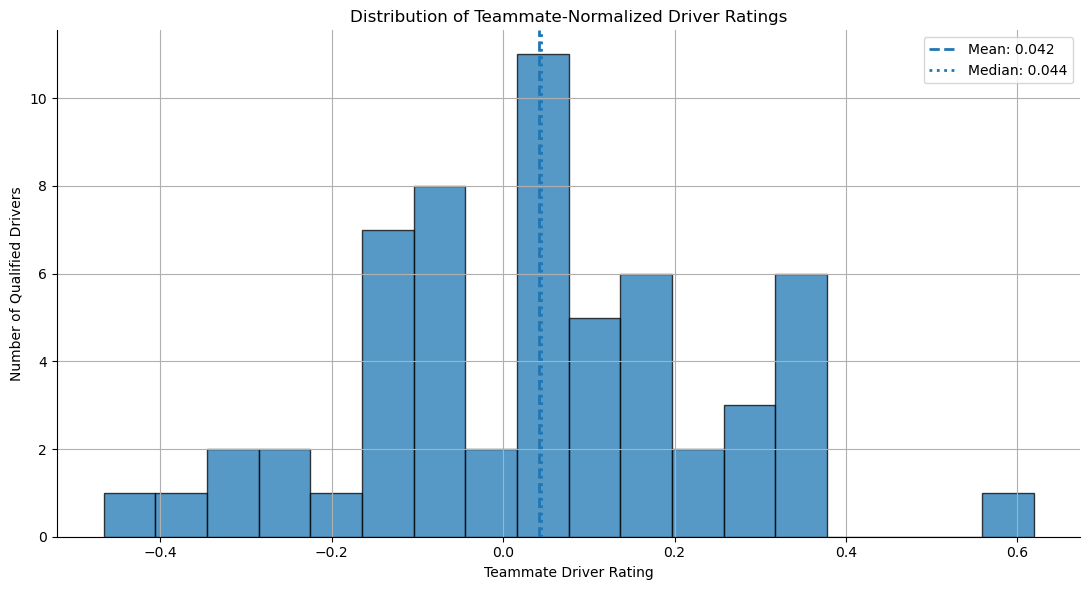

Saved figure: /Users/lukeweeklund/F1 Project/data/outputs/figures/rating_distribution.png


In [18]:
# ==============================================================================
# CELL 6 — RATING DISTRIBUTION
# ==============================================================================

fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    qualified["teammate_driver_rating"],
    bins=18,
    edgecolor="black",
    alpha=0.75,
)

mean_rating = qualified["teammate_driver_rating"].mean()
median_rating = qualified["teammate_driver_rating"].median()

ax.axvline(mean_rating, linestyle="--", linewidth=2, label=f"Mean: {mean_rating:.3f}")
ax.axvline(median_rating, linestyle=":", linewidth=2, label=f"Median: {median_rating:.3f}")

ax.set_title("Distribution of Teammate-Normalized Driver Ratings")
ax.set_xlabel("Teammate Driver Rating")
ax.set_ylabel("Number of Qualified Drivers")
ax.legend()

fig.tight_layout()

rating_distribution_path = FIGURES / "rating_distribution.png"
fig.savefig(rating_distribution_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure: {rating_distribution_path}")

## Cell 7 — Driver vs Car Independence

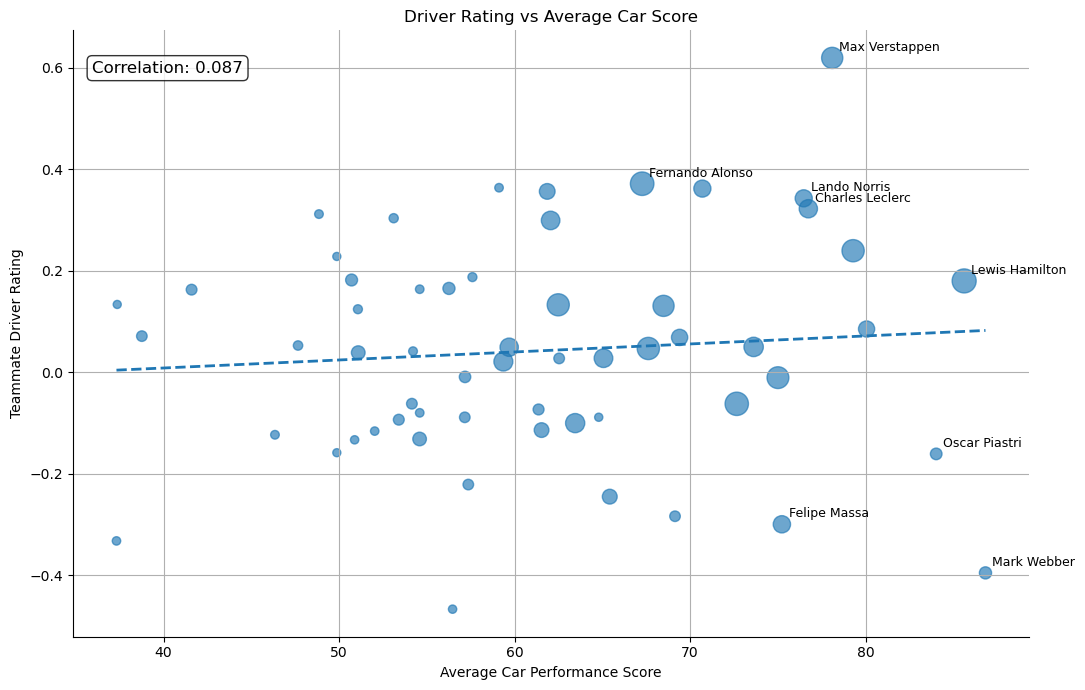

Saved figure: /Users/lukeweeklund/F1 Project/data/outputs/figures/driver_rating_vs_car_score.png


In [19]:
# ==============================================================================
# CELL 7 — DRIVER VS CAR INDEPENDENCE
# ==============================================================================

if "avg_car_score" not in qualified.columns:
    raise ValueError("avg_car_score is required for the driver-vs-car independence plot.")

plot_data = qualified.dropna(subset=["teammate_driver_rating", "avg_car_score"]).copy()

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    plot_data["avg_car_score"],
    plot_data["teammate_driver_rating"],
    s=np.clip(plot_data["races"], 30, 300),
    alpha=0.65,
)

x = plot_data["avg_car_score"].values
y = plot_data["teammate_driver_rating"].values

if len(plot_data) > 1:
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = m * x_line + b
    ax.plot(x_line, y_line, linestyle="--", linewidth=2)

corr_value = plot_data["teammate_driver_rating"].corr(plot_data["avg_car_score"])

ax.set_title("Driver Rating vs Average Car Score")
ax.set_xlabel("Average Car Performance Score")
ax.set_ylabel("Teammate Driver Rating")
ax.text(
    0.02,
    0.95,
    f"Correlation: {corr_value:.3f}",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8},
)

label_drivers = [
    "Max Verstappen",
    "Lewis Hamilton",
    "Fernando Alonso",
    "Lando Norris",
    "Charles Leclerc",
    "Oscar Piastri",
    "Mark Webber",
    "Felipe Massa",
]

for _, row in plot_data[plot_data["driver_name"].isin(label_drivers)].iterrows():
    ax.annotate(
        row["driver_name"],
        (row["avg_car_score"], row["teammate_driver_rating"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

fig.tight_layout()

driver_vs_car_path = FIGURES / "driver_rating_vs_car_score.png"
fig.savefig(driver_vs_car_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure: {driver_vs_car_path}")

## Cell 8 — Reliability Analysis

Reliability distribution across all rated drivers:
reliability
Low         25
Moderate    32
Medium       7
High        19
Name: count, dtype: int64


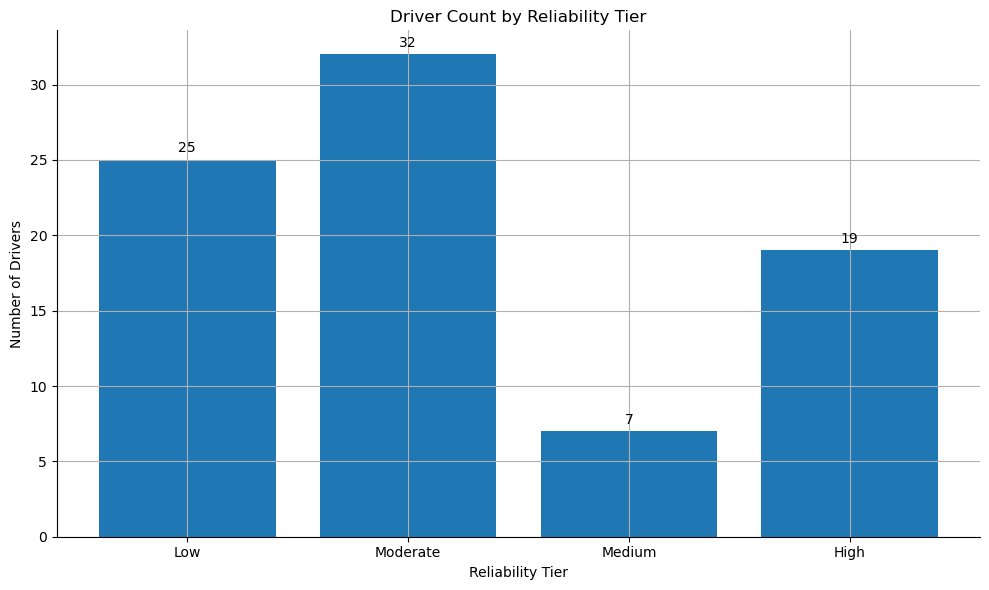

Saved figure: /Users/lukeweeklund/F1 Project/data/outputs/figures/reliability_counts.png


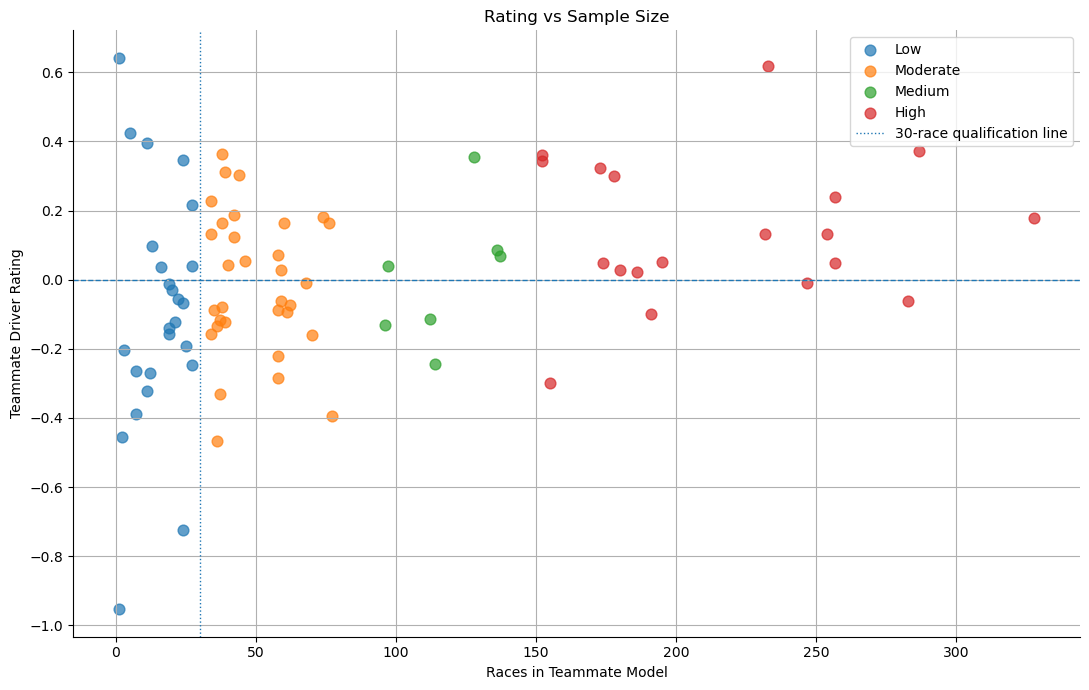

Saved figure: /Users/lukeweeklund/F1 Project/data/outputs/figures/rating_vs_races.png


In [20]:
# ==============================================================================
# CELL 8 — RELIABILITY ANALYSIS
# ==============================================================================

reliability_order = ["Low", "Moderate", "Medium", "High"]

reliability_counts = (
    ratings_all["reliability"]
    .value_counts()
    .reindex(reliability_order)
    .dropna()
    .astype(int)
)

print("Reliability distribution across all rated drivers:")
print(reliability_counts)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(reliability_counts.index, reliability_counts.values)
ax.set_title("Driver Count by Reliability Tier")
ax.set_xlabel("Reliability Tier")
ax.set_ylabel("Number of Drivers")

for i, value in enumerate(reliability_counts.values):
    ax.text(i, value + 0.5, str(value), ha="center")

fig.tight_layout()

reliability_counts_path = FIGURES / "reliability_counts.png"
fig.savefig(reliability_counts_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {reliability_counts_path}")

fig, ax = plt.subplots(figsize=(11, 7))

for tier in reliability_order:
    subset = ratings_all[ratings_all["reliability"] == tier]
    if len(subset) == 0:
        continue
    ax.scatter(
        subset["races"],
        subset["teammate_driver_rating"],
        alpha=0.7,
        label=tier,
        s=60,
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.axvline(30, linestyle=":", linewidth=1, label="30-race qualification line")
ax.set_title("Rating vs Sample Size")
ax.set_xlabel("Races in Teammate Model")
ax.set_ylabel("Teammate Driver Rating")
ax.legend()

fig.tight_layout()

rating_vs_races_path = FIGURES / "rating_vs_races.png"
fig.savefig(rating_vs_races_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {rating_vs_races_path}")

## Cell 9 — Driver Case Studies

In [21]:
# ==============================================================================
# CELL 9 — DRIVER CASE STUDIES
# ==============================================================================

case_study_drivers = [
    "Max Verstappen",
    "Fernando Alonso",
    "Lewis Hamilton",
    "Lando Norris",
    "Oscar Piastri",
    "Mark Webber",
    "Felipe Massa",
    "Rubens Barrichello",
    "Pascal Wehrlein",
    "Mick Schumacher",
]

case_cols = [
    "qualified_rank",
    "driver_name",
    "teammate_driver_rating",
    "reliability",
    "races",
    "teammate_win_rate",
    "avg_finish_gap",
    "qualifying_win_rate",
    "avg_points_gap",
    "avg_car_score",
]
case_cols = [c for c in case_cols if c in qualified.columns]

case_studies = (
    qualified[qualified["driver_name"].isin(case_study_drivers)]
    .sort_values("teammate_driver_rating", ascending=False)
    [case_cols]
)

display(case_studies)

print("Case study notes:")
print("- Verstappen rates first because his teammate win rate and finish-gap metrics are both elite across a large sample.")
print("- Alonso rates very highly because his teammate record is strong across many seasons, teams, and teammate contexts.")
print("- Hamilton rates lower than raw championship reputation might suggest because the model only measures 2010–2025 teammate-relative outcomes.")
print("- Piastri rates low in this dataset because the available sample shows him trailing Norris on teammate wins, qualifying wins, finish gap, and points gap.")
print("- Webber and Massa rate low largely because their samples include difficult teammate comparisons against Vettel and Alonso.")
print("- Barrichello, Wehrlein, and Schumacher are useful but need caution because their samples are much smaller than the highest-reliability drivers.")

,qualified_rank,driver_name,teammate_driver_rating,reliability,races,teammate_win_rate,avg_finish_gap,qualifying_win_rate,avg_points_gap,avg_car_score
0,1,Max Verstappen,0.619023,High,233,0.759657,2.948498,0.751073,6.633047,78.086667
1,2,Fernando Alonso,0.371284,High,287,0.672474,1.839721,0.749129,3.149826,67.260774
2,3,Rubens Barrichello,0.363370,Moderate,38,0.684211,2.736842,0.605263,0.736842,59.108411
5,6,Lando Norris,0.342500,High,152,0.631579,1.210526,0.671053,1.756579,76.464358
7,8,Pascal Wehrlein,0.311484,Moderate,39,0.615385,0.564103,0.666667,0.153846,48.850476
8,9,Mick Schumacher,0.303364,Moderate,44,0.681818,0.340909,0.613636,-0.204545,53.106814
14,15,Lewis Hamilton,0.179860,High,328,0.579268,0.625000,0.560976,1.971037,85.602577
50,51,Oscar Piastri,-0.160738,Moderate,70,0.328571,-1.185714,0.300000,-2.771429,84.010469
54,55,Felipe Massa,-0.299364,High,155,0.341935,-2.212903,0.335484,-4.058065,75.219746
56,57,Mark Webber,-0.395057,Moderate,77,0.233766,-2.090909,0.246753,-5.818182,86.817248


Case study notes:
- Verstappen rates first because his teammate win rate and finish-gap metrics are both elite across a large sample.
- Alonso rates very highly because his teammate record is strong across many seasons, teams, and teammate contexts.
- Hamilton rates lower than raw championship reputation might suggest because the model only measures 2010–2025 teammate-relative outcomes.
- Piastri rates low in this dataset because the available sample shows him trailing Norris on teammate wins, qualifying wins, finish gap, and points gap.
- Webber and Massa rate low largely because their samples include difficult teammate comparisons against Vettel and Alonso.
- Barrichello, Wehrlein, and Schumacher are useful but need caution because their samples are much smaller than the highest-reliability drivers.


## Cell 10 — Robustness Review

Gap cap sensitivity:


,gap_cap,drivers_compared,corr_with_main_rating
0,8,58,0.981450
1,10,58,0.981889
2,12,58,0.982035
3,15,58,0.981477
4,20,58,0.980952



Minimum race threshold sensitivity:


,min_races,qualified_drivers,top_driver,top_rating,rating_std
0,10,76,Max Verstappen,0.619023,0.228875
1,20,68,Max Verstappen,0.619023,0.229286
2,30,58,Max Verstappen,0.619023,0.215394
3,50,40,Max Verstappen,0.619023,0.212350
4,75,28,Max Verstappen,0.619023,0.226100
5,100,24,Max Verstappen,0.619023,0.215348
6,150,19,Max Verstappen,0.619023,0.211990


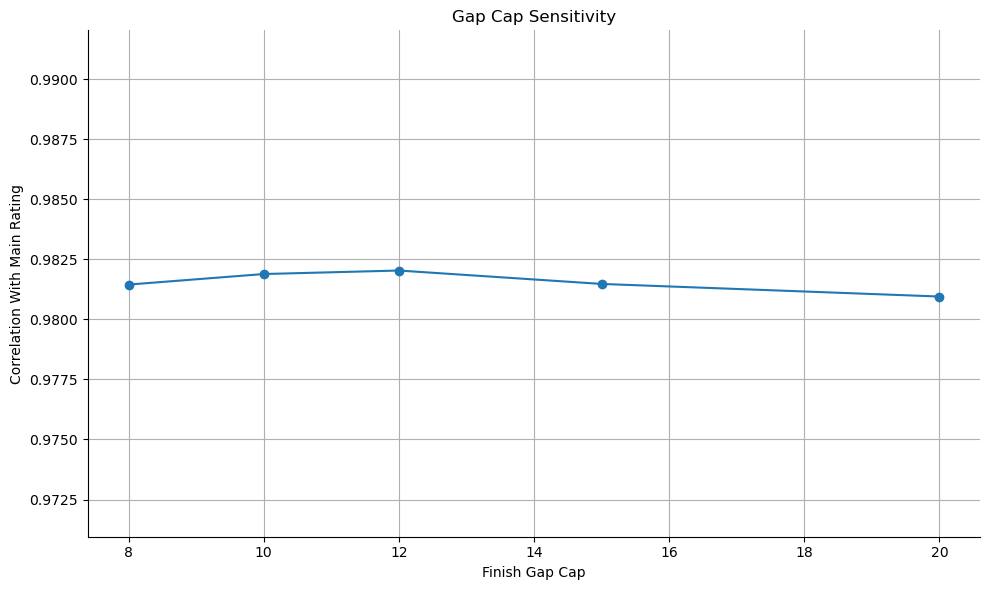

Saved figure: /Users/lukeweeklund/F1 Project/data/outputs/figures/gap_cap_sensitivity.png


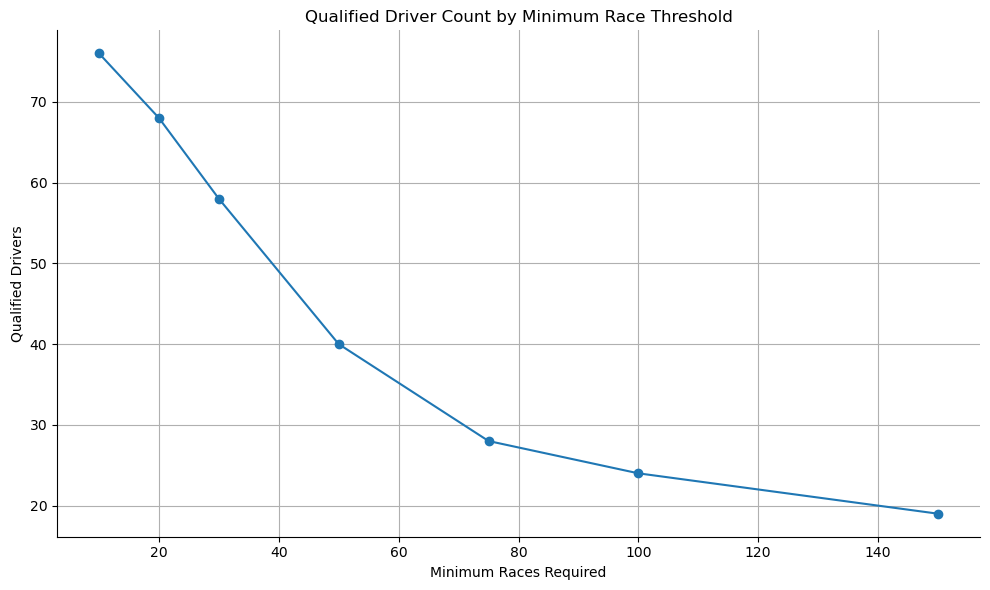

Saved figure: /Users/lukeweeklund/F1 Project/data/outputs/figures/min_race_threshold_sensitivity.png

Interpretation:
The gap-cap sensitivity correlations are very high, which means the main leaderboard is not dependent on one exact finish-gap cap. The minimum-race table shows the tradeoff between inclusiveness and reliability.


In [22]:
# ==============================================================================
# CELL 10 — ROBUSTNESS REVIEW
# ==============================================================================

print("Gap cap sensitivity:")
display(gap_cap_sensitivity)

print("\nMinimum race threshold sensitivity:")
display(min_race_sensitivity)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    gap_cap_sensitivity["gap_cap"],
    gap_cap_sensitivity["corr_with_main_rating"],
    marker="o",
)

ax.set_title("Gap Cap Sensitivity")
ax.set_xlabel("Finish Gap Cap")
ax.set_ylabel("Correlation With Main Rating")
ax.set_ylim(
    max(0, gap_cap_sensitivity["corr_with_main_rating"].min() - 0.01),
    min(1.0, gap_cap_sensitivity["corr_with_main_rating"].max() + 0.01),
)

fig.tight_layout()

gap_cap_path = FIGURES / "gap_cap_sensitivity.png"
fig.savefig(gap_cap_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {gap_cap_path}")

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    min_race_sensitivity["min_races"],
    min_race_sensitivity["qualified_drivers"],
    marker="o",
)

ax.set_title("Qualified Driver Count by Minimum Race Threshold")
ax.set_xlabel("Minimum Races Required")
ax.set_ylabel("Qualified Drivers")

fig.tight_layout()

min_race_path = FIGURES / "min_race_threshold_sensitivity.png"
fig.savefig(min_race_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {min_race_path}")

print("\nInterpretation:")
print(
    "The gap-cap sensitivity correlations are very high, which means the main leaderboard is not dependent "
    "on one exact finish-gap cap. The minimum-race table shows the tradeoff between inclusiveness and reliability."
)

## Cell 11 — Portfolio Conclusions

In [23]:
# ==============================================================================
# CELL 11 — PORTFOLIO CONCLUSIONS
# ==============================================================================

conclusions = [
    "The teammate-normalized model is a more defensible way to estimate driver performance than raw finishing position.",
    "The final rating has low correlation with average car score, which suggests the model is not simply recreating constructor strength.",
    "The rating strongly tracks direct teammate outcomes, especially teammate win rate and average finish gap.",
    "High-sample drivers should be interpreted with more confidence than moderate-sample drivers.",
    "Small-sample high performers are not necessarily wrong, but they should be clearly labeled as lower reliability.",
    "Some surprising low rankings, including Piastri, Webber, and Massa, are explainable from teammate-relative statistics.",
    "DNF handling is the most important future modeling improvement because mechanical failures can distort race-level teammate comparisons.",
    "A future Bayesian or Elo-style model could improve uncertainty treatment and driver-linking across teams and eras.",
]

print("Portfolio-ready conclusions:")
for i, conclusion in enumerate(conclusions, start=1):
    print(f"{i}. {conclusion}")

limitations = [
    "The model covers 2010–2025 only, so older-career context is not represented for drivers whose careers started earlier.",
    "Mechanical DNFs are not excluded yet because the final dataset does not currently include a trusted upstream mechanical-DNF flag.",
    "The model is teammate-relative, so ratings depend partly on the strength and timing of each driver's teammate network.",
    "Circuit metadata includes analyst-coded ratings, which are useful context features but not official F1 measurements.",
]

print("\nLimitations:")
for i, limitation in enumerate(limitations, start=1):
    print(f"{i}. {limitation}")

future_work = [
    "Build a trusted mechanical-DNF flag upstream and rerun Notebook 5 as a robustness test.",
    "Add confidence intervals or posterior intervals using a Bayesian hierarchical model.",
    "Create a dashboard view with leaderboard filtering by reliability, era, constructor, and teammate.",
    "Compare teammate model results against Elo-style driver ratings.",
]

print("\nFuture work:")
for i, item in enumerate(future_work, start=1):
    print(f"{i}. {item}")

Portfolio-ready conclusions:
1. The teammate-normalized model is a more defensible way to estimate driver performance than raw finishing position.
2. The final rating has low correlation with average car score, which suggests the model is not simply recreating constructor strength.
3. The rating strongly tracks direct teammate outcomes, especially teammate win rate and average finish gap.
4. High-sample drivers should be interpreted with more confidence than moderate-sample drivers.
5. Small-sample high performers are not necessarily wrong, but they should be clearly labeled as lower reliability.
6. Some surprising low rankings, including Piastri, Webber, and Massa, are explainable from teammate-relative statistics.
7. DNF handling is the most important future modeling improvement because mechanical failures can distort race-level teammate comparisons.
8. A future Bayesian or Elo-style model could improve uncertainty treatment and driver-linking across teams and eras.

Limitations:
1. 

## Cell 12 — Export Figure Manifest

In [24]:
# ==============================================================================
# CELL 12 — EXPORT FIGURE MANIFEST
# ==============================================================================

figure_files = sorted(FIGURES.glob("*.png"))

manifest = pd.DataFrame(
    {
        "figure_file": [f.name for f in figure_files],
        "path": [str(f) for f in figure_files],
    }
)

manifest_path = OUTPUTS / "notebook_06_figure_manifest.csv"
manifest.to_csv(manifest_path, index=False)

print("Figure manifest:")
display(manifest)

print(f"\nSaved manifest: {manifest_path}")
print("\nFinal notebook verdict: Notebook 6 is ready after Notebook 5 outputs exist.")

Figure manifest:


,figure_file,path
0,driver_rating_vs_car_score.png,/Users/lukeweeklund/F1 Project/data/outputs/figures/driver_rating_vs_car_sco...
1,gap_cap_sensitivity.png,/Users/lukeweeklund/F1 Project/data/outputs/figures/gap_cap_sensitivity.png
2,min_race_threshold_sensitivity.png,/Users/lukeweeklund/F1 Project/data/outputs/figures/min_race_threshold_sensi...
3,rating_distribution.png,/Users/lukeweeklund/F1 Project/data/outputs/figures/rating_distribution.png
4,rating_vs_races.png,/Users/lukeweeklund/F1 Project/data/outputs/figures/rating_vs_races.png
5,reliability_counts.png,/Users/lukeweeklund/F1 Project/data/outputs/figures/reliability_counts.png



Saved manifest: /Users/lukeweeklund/F1 Project/data/outputs/notebook_06_figure_manifest.csv

Final notebook verdict: Notebook 6 is ready after Notebook 5 outputs exist.
